In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"(one value per feature, per transaction)")

SHAP values shape: (56962, 30)
(one value per feature, per transaction)


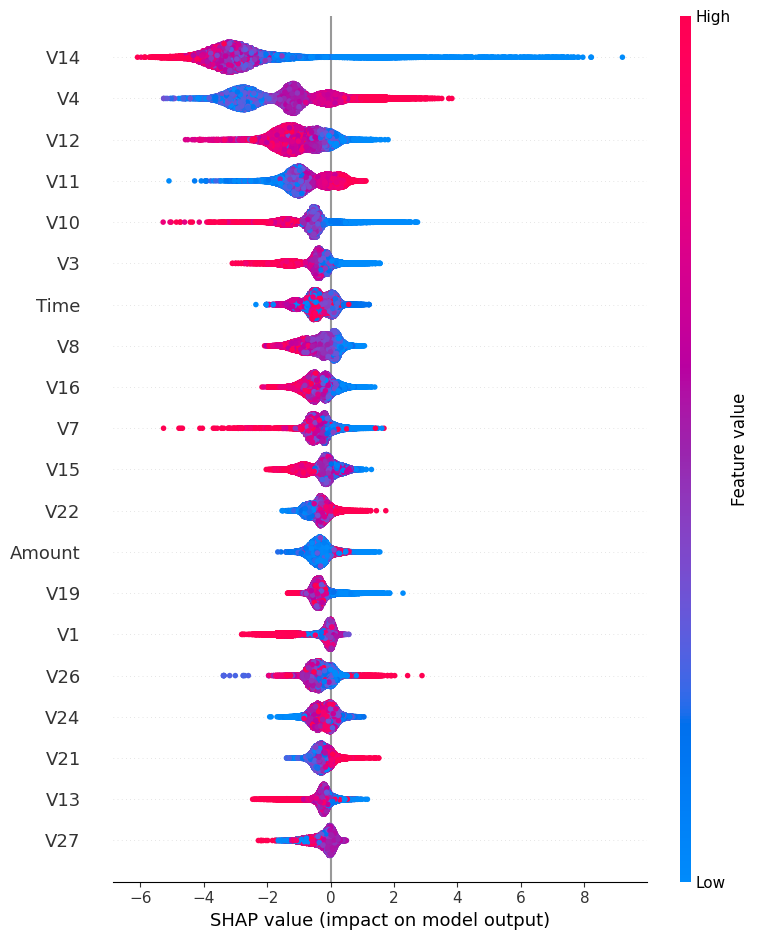

In [3]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("../outputs/07_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

Transaction index: 37511
Model confidence: 1.0000
Actually fraud: True


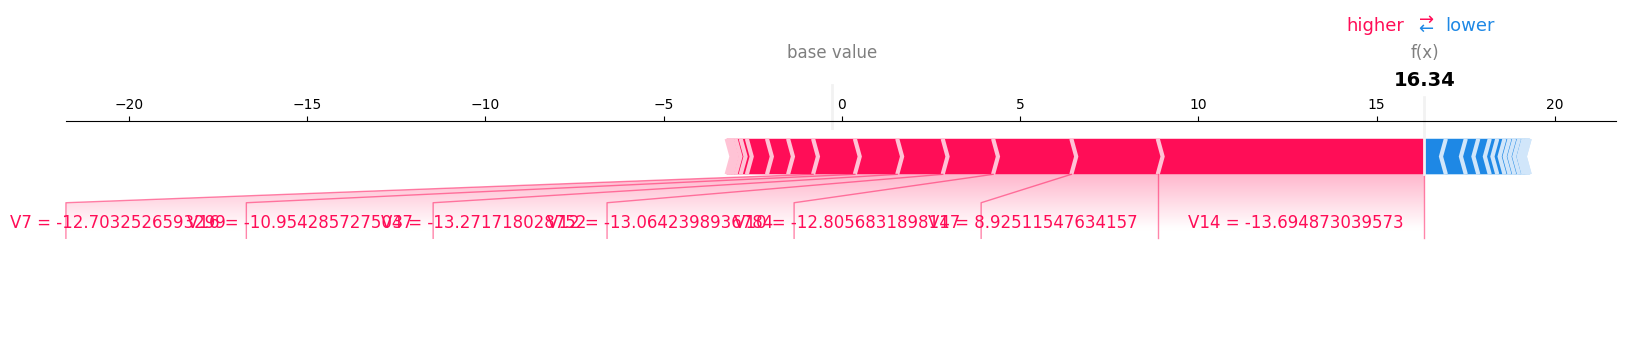

In [4]:
# Pick a fraud case the model confidently flagged
fraud_idx_in_test = np.where(y_test.values == 1)[0]
proba = model.predict_proba(X_test)[:, 1]
most_confident_fraud = fraud_idx_in_test[np.argmax(proba[fraud_idx_in_test])]

print(f"Transaction index: {most_confident_fraud}")
print(f"Model confidence: {proba[most_confident_fraud]:.4f}")
print(f"Actually fraud: {y_test.iloc[most_confident_fraud] == 1}")

shap.force_plot(
    explainer.expected_value, 
    shap_values[most_confident_fraud], 
    X_test.iloc[most_confident_fraud],
    matplotlib=True, show=False
)
plt.savefig("../outputs/07_shap_single_transaction.png", dpi=150, bbox_inches='tight')
plt.show()

Transaction index: 12266
Model confidence: 0.4416


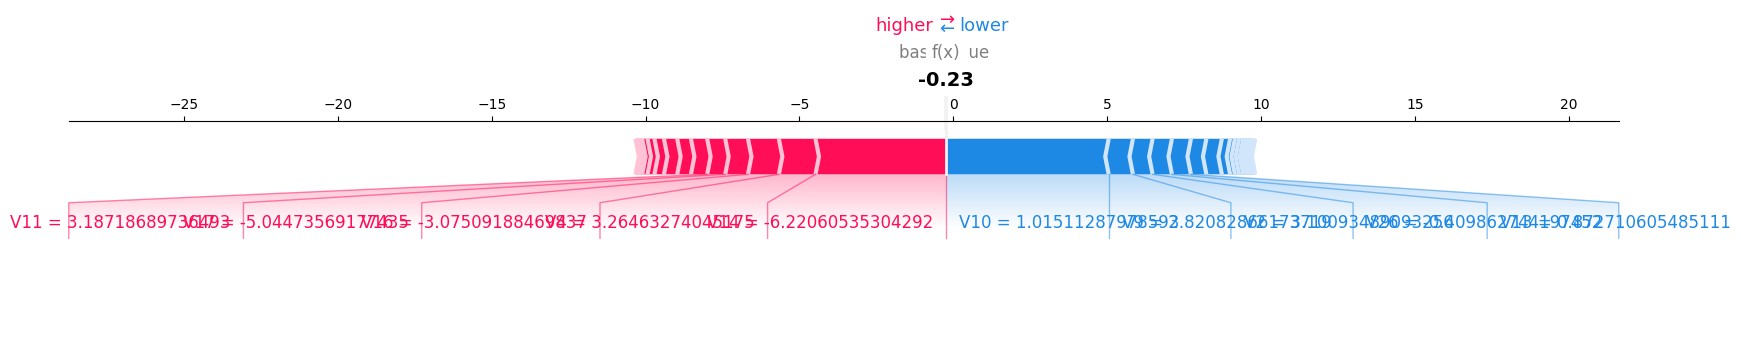

In [5]:
# Find a fraud case with LOWER confidence — a harder, more realistic example
fraud_idx_in_test = np.where(y_test.values == 1)[0]
proba = model.predict_proba(X_test)[:, 1]
fraud_probas = proba[fraud_idx_in_test]

# Pick one closest to 0.5-0.7 range — genuinely uncertain
uncertain_mask = (fraud_probas > 0.4) & (fraud_probas < 0.8)
if uncertain_mask.sum() > 0:
    uncertain_fraud = fraud_idx_in_test[uncertain_mask][0]
    print(f"Transaction index: {uncertain_fraud}")
    print(f"Model confidence: {proba[uncertain_fraud]:.4f}")
    
    shap.force_plot(
        explainer.expected_value,
        shap_values[uncertain_fraud],
        X_test.iloc[uncertain_fraud],
        matplotlib=True, show=False
    )
    plt.savefig("../outputs/07_shap_uncertain_case.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No fraud cases in that confidence range — model is very decisive either way")